# Project: Hotel Booking Cancellation Prediction 
> Task: You are provided with a dataset of hotel bookings. The goal is to predict whether a booking will be canceled based on various features such as lead time, number of guests, meal preferences, and others. Your task is to build a classification model to predict the target variable is canceled, which indicates whether a booking was canceled (1) or not (0).

@Yevheniia-Rudenko 


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import os
from imblearn.over_sampling import SMOTE



from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    roc_curve,
    auc
)

## Data overview

In [2]:
# Load labeled and unlabeled data
labeled_data = pd.read_csv("/Users/yevrud/redi_school_ML_AI/final_project/data/train.csv")
unlabeled_data = pd.read_csv("/Users/yevrud/redi_school_ML_AI/final_project/data/test.csv")

# Create copies of the datasets
df_train = labeled_data.copy()
df_test = unlabeled_data.copy()

# Save test IDs for final output
test_ids = df_test["id"].copy()


In [3]:
df_train.info()
df_train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83573 entries, 0 to 83572
Data columns (total 39 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           83573 non-null  object 
 1   is_canceled                     83573 non-null  int64  
 2   lead_time                       79290 non-null  float64
 3   arrival_date_year               83573 non-null  int64  
 4   arrival_date_month              83573 non-null  object 
 5   arrival_date_week_number        83573 non-null  int64  
 6   arrival_date_day_of_month       83573 non-null  int64  
 7   stays_in_weekend_nights         83573 non-null  float64
 8   stays_in_week_nights            83573 non-null  float64
 9   adults                          83573 non-null  int64  
 10  children                        83571 non-null  float64
 11  babies                          83573 non-null  int64  
 12  meal                            

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,id,estimated_check_in_duration,booking_difficulty_score
count,83573.000000,79290.000000,83573.000000,83573.000000,83573.000000,83573.000000,83573.000000,83573.000000,83571.000000,83573.000000,...,83573.000000,72224.000000,4674.000000,83573.000000,79290.000000,83573.000000,83573.000000,83573.000000,79290.000000,79290.000000
mean,0.397210,103.379569,27.120326,2016.155912,15.788077,0.928752,2.492898,1.859225,0.102918,0.008137,...,0.220681,86.603774,186.998074,2.321765,101.735184,0.061790,0.572745,59698.368983,51.673768,1.293816
std,0.489323,119.376604,13.619669,0.707381,8.782488,1.118739,2.126703,0.594781,0.397277,0.096017,...,0.654785,110.672677,130.511313,19.326393,57.456359,0.243445,0.794273,34498.851794,60.534659,2.294587
min,0.000000,-227.156938,1.000000,2015.000000,1.000000,-1.791310,-3.794357,0.000000,0.000000,0.000000,...,0.000000,1.000000,9.000000,-36.442446,-80.136040,0.000000,0.000000,1.000000,-123.491940,-5.127325
25%,0.000000,18.369438,16.000000,2016.000000,8.000000,0.065392,1.105973,2.000000,0.000000,0.000000,...,0.000000,9.000000,59.000000,-5.701373,65.609982,0.000000,0.000000,29788.000000,8.512819,0.103028
50%,0.000000,79.567680,27.000000,2016.000000,16.000000,0.795712,2.217654,2.000000,0.000000,0.000000,...,0.000000,14.000000,174.000000,0.394790,96.152208,0.000000,0.000000,59782.000000,40.426761,1.090596
75%,1.000000,167.570697,38.000000,2017.000000,23.000000,1.713242,3.551786,2.000000,0.000000,0.000000,...,0.000000,229.000000,268.000000,6.589958,131.647735,0.000000,1.000000,89525.000000,84.541252,2.131485
max,1.000000,741.651834,53.000000,2017.000000,31.000000,19.232182,49.354003,55.000000,10.000000,9.000000,...,20.000000,535.000000,543.000000,401.792112,5411.546686,8.000000,5.000000,119390.000000,370.155876,55.593803


In [4]:
df_train.isnull().sum().sort_values(ascending=False)[lambda x : x > 0]

company                        78899
agent                          11349
country                         4540
meal                            4283
adr                             4283
booking_difficulty_score        4283
estimated_check_in_duration     4283
lead_time                       4283
children                           2
dtype: int64

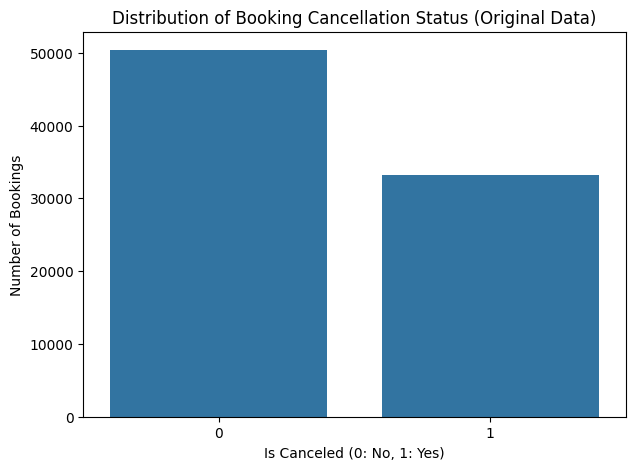

In [5]:
# Distribution of Target Variable 'is_canceled' (Before Cleaning/Outlier Removal) ---
plt.figure(figsize=(7, 5))
sns.countplot(x='is_canceled', data=df_train)
plt.title('Distribution of Booking Cancellation Status (Original Data)')
plt.xlabel('Is Canceled (0: No, 1: Yes)')
plt.ylabel('Number of Bookings')
plt.show()

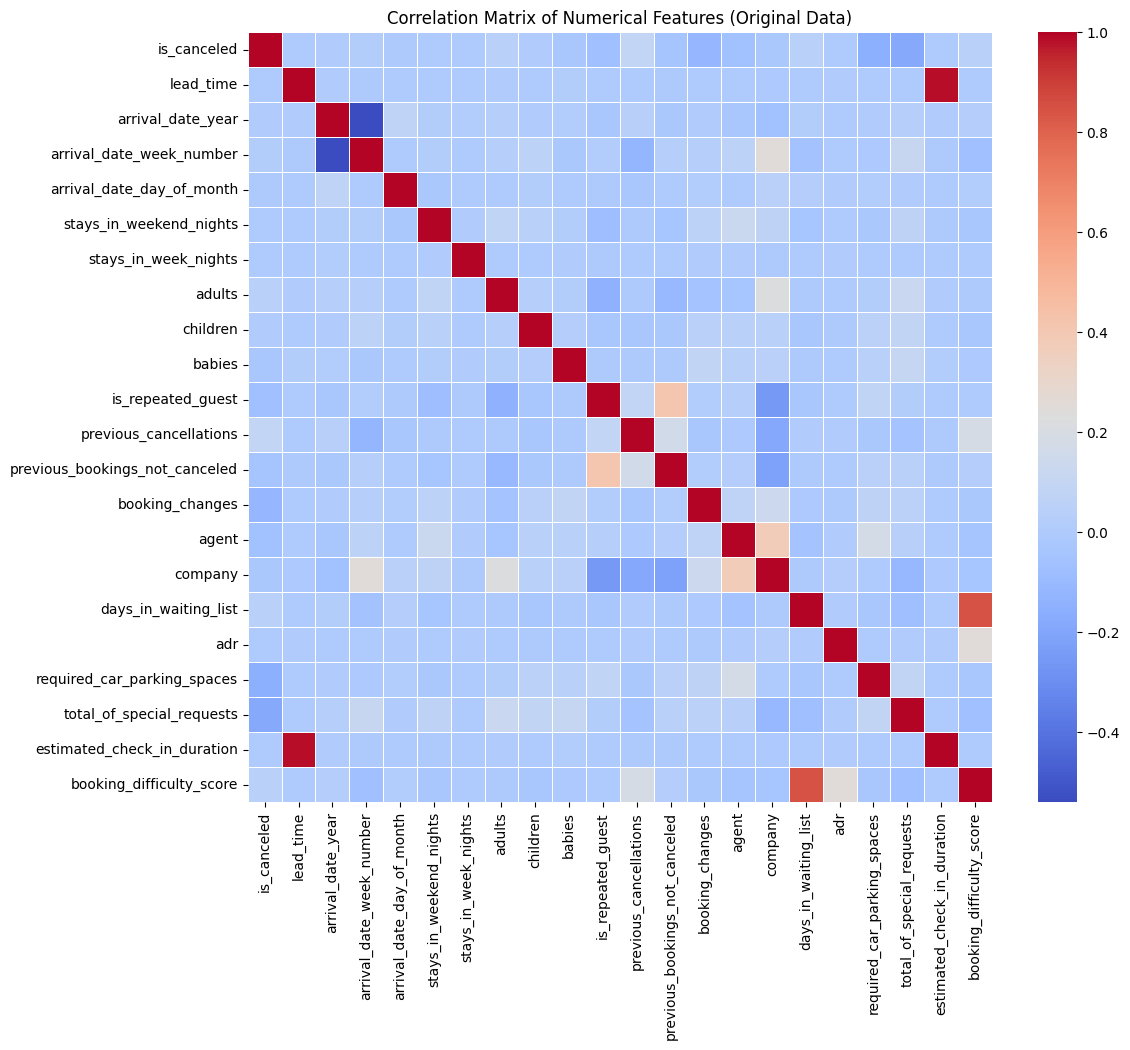

In [6]:
#Correlation Matrix of Numerical Features (Before Cleaning) ---
# Select only numerical columns for correlation
numerical_df_initial = df_train.select_dtypes(include=['float64', 'int64']).drop(columns=['id'], errors='ignore')
plt.figure(figsize=(12, 10))
sns.heatmap(numerical_df_initial.corr(), annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features (Original Data)')
plt.show()

## Data Cleaning and preprocessing

In [7]:
def clean_data(df):
    df = df.copy()

    # Handle negative values in 'lead_time' and fill missing values with the median
    df['lead_time'] = df['lead_time'].apply(lambda x: np.nan if x < 0 else x)
    df['lead_time'] = df['lead_time'].fillna(df['lead_time'].median())

    # Handle negative values in 'adr' and fill missing values with the median
    df['adr'] = df['adr'].apply(lambda x: np.nan if x < 0 else x)
    df['adr'] = df['adr'].fillna(df['adr'].median())

    # Fill missing 'children' with 0 and remove negative values
    df['children'] = df['children'].fillna(0).apply(lambda x: max(0, x))

    # Ensure 'babies' has no negative values
    if 'babies' in df.columns:
        df['babies'] = df['babies'].apply(lambda x: max(0, x))

    # Clean 'estimated_check_in_duration' by removing negatives and filling with median
    if 'estimated_check_in_duration' in df.columns:
        df['estimated_check_in_duration'] = df['estimated_check_in_duration'].apply(
            lambda x: np.nan if x < 0 else x
        )
        df['estimated_check_in_duration'] = df['estimated_check_in_duration'].fillna(
            df['estimated_check_in_duration'].median()
        )

    # Fix unrealistic values in 'arrival_date_year'
    if 'arrival_date_year' in df.columns:
        valid_years = df['arrival_date_year'][df['arrival_date_year'] >= 1990]
        mode_year = valid_years.mode()[0] if not valid_years.empty else 2017
        df['arrival_date_year'] = df['arrival_date_year'].apply(
            lambda x: x if x >= 1990 else mode_year
        )

    # Replace invalid 'arrival_date_month' values with the mode
    if 'arrival_date_month' in df.columns:
        valid_months = [
            'January', 'February', 'March', 'April', 'May', 'June',
            'July', 'August', 'September', 'October', 'November', 'December'
        ]
        mode_month = df[df['arrival_date_month'].isin(valid_months)]['arrival_date_month'].mode()[0]
        df['arrival_date_month'] = df['arrival_date_month'].apply(
            lambda x: x if x in valid_months else mode_month
        )

    # Fill missing values in 'booking_difficulty_score' with the median
    if 'booking_difficulty_score' in df.columns:
        df['booking_difficulty_score'] = df['booking_difficulty_score'].fillna(
            df['booking_difficulty_score'].median()
        )

    # Fill missing values in categorical features with mode
    for col in ['meal', 'country']:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].mode()[0])

    # Fill missing values in numeric ID features with 0
    for col in ['agent', 'company']:
        if col in df.columns:
            df[col] = df[col].fillna(0)

    # Drop confidential columns if present
    confidential_cols = ['name', 'email', 'phone-number', 'credit_card']
    df = df.drop(columns=[col for col in confidential_cols if col in df.columns])

    # Drop data leakage columns
    leakage_cols = [
        'reservation_status', 'reservation_status_Check-Out', 'reservation_status_Canceled',
        'reservation_status_No-Show', 'estimated_check_in_duration', 'assigned_room_type',
        'reservation_status_date'
    ]
    df = df.drop(columns=[col for col in leakage_cols if col in df.columns], errors='ignore')

    return df



In [8]:
def remove_outliers(df, columns, threshold=2.0):
    df_copy = df.copy()
    for col in columns:
        if col in df_copy.columns and pd.api.types.is_numeric_dtype(df_copy[col]):
            Q1 = df_copy[col].quantile(0.25)
            Q3 = df_copy[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - threshold * IQR
            upper = Q3 + threshold * IQR
            df_copy = df_copy[(df_copy[col] >= lower) & (df_copy[col] <= upper)]
    return df_copy

In [9]:
def feature_engineer(df):
    df = df.copy()
    df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
    df['total_guests'] = df['adults'] + df['children'] + df['babies']
    df['adr_per_person'] = df.apply(lambda row: row['adr'] / row['total_guests'] if row['total_guests'] > 0 else 0, axis=1)
    df['cancellation_ratio_prev_bookings'] = df.apply(
        lambda row: row['previous_cancellations'] / (row['previous_cancellations'] + row['previous_bookings_not_canceled'])
        if (row['previous_cancellations'] + row['previous_bookings_not_canceled']) > 0 else 0, axis=1)
    df['is_direct_booking'] = ((df['agent'] == 0) & (df['company'] == 0)).astype(int)
    return df

In [10]:
# Clean and engineer data
df_train = clean_data(df_train)
df_test = clean_data(df_test)
df_train = feature_engineer(df_train)
df_test = feature_engineer(df_test)

In [11]:
# Outlier removal
outlier_cols = [col for col in df_train.select_dtypes(include=['float64', 'int64']).columns if col not in ['id', 'is_canceled']]
df_train = remove_outliers(df_train, outlier_cols)

In [12]:
print("Missing Values After Cleaning")
missing_values_cleaned = df_train.isnull().sum().sort_values(ascending=False)
print(missing_values_cleaned[missing_values_cleaned > 0]) # Should be empty for cleaned columns

Missing Values After Cleaning
Series([], dtype: int64)


In [13]:
# Save cleaned data to CSV files for reuse
df_train.to_csv('clean_train.csv', index=False)
df_test.to_csv('clean_test.csv', index=False) # Saving test data as well, useful for debugging


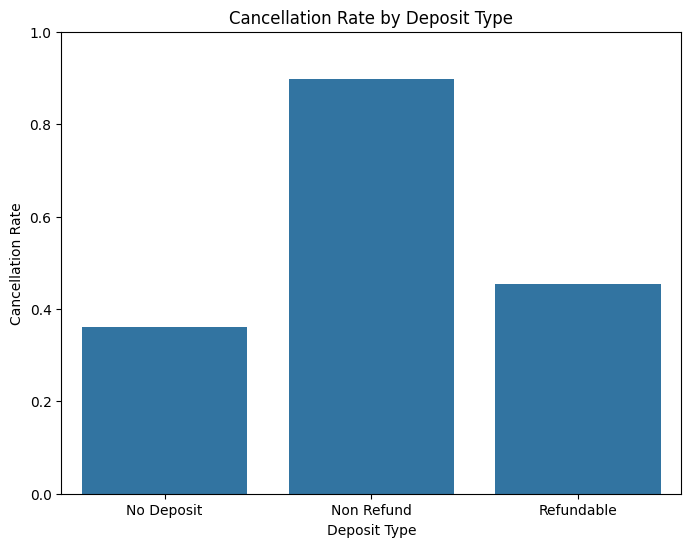

In [14]:
# Plot: Cancellation Percentage by Deposit Type 
plt.figure(figsize=(8, 6))
deposit_cancellation_rate = df_train.groupby('deposit_type')['is_canceled'].value_counts(normalize=True).unstack()
if 1 in deposit_cancellation_rate.columns:
    sns.barplot(x=deposit_cancellation_rate.index, y=deposit_cancellation_rate[1])
else:
    # Handle case where no cancellations for a deposit type exist
    plt.text(0.5, 0.5, "No cancellations observed for deposit types in the filtered data.",
             horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)
plt.title('Cancellation Rate by Deposit Type')
plt.xlabel('Deposit Type')
plt.ylabel('Cancellation Rate')
plt.ylim(0, 1) # Ensure y-axis is from 0 to 1 for rates
plt.show()

## Encode Categorical Features

In [15]:
# Identify categorical columns (object dtype)
categorical_cols = df_train.select_dtypes(include='object').columns.tolist()

# Apply One-Hot Encoding
df_train = pd.get_dummies(df_train, columns=categorical_cols, drop_first=True)
df_test = pd.get_dummies(df_test, columns=categorical_cols, drop_first=True)

# Align columns between train and test after one-hot encoding
# The target 'is_canceled' is dropped from X later, and 'id' from X or kept separate.
train_cols_for_alignment = df_train.columns.drop(["is_canceled", "id"], errors='ignore').tolist()
df_test = df_test.reindex(columns=train_cols_for_alignment, fill_value=0)

## Split the train data set into train/val/test

In [16]:
# Split the train data set into train/val/test
X = df_train.drop(["is_canceled", "id"], axis=1, errors='ignore') # Ensure 'id' is dropped from features
y = df_train["is_canceled"]

# First split: 60% train, 40% temp
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)

# Second split: 20% val, 20% test_eval (from original train data, for evaluation purposes)
X_val, X_test_eval, y_val, y_test_eval = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)


In [17]:
# Save feature means
feature_means = X.mean().reset_index()
feature_means.columns = ["Feature", "Mean"]
feature_means.to_csv("feature_means.csv", index=False)

In [18]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Original train label distribution:\n{y_train.value_counts()}")
print(f"After SMOTE train label distribution:\n{pd.Series(y_train_res).value_counts()}")

Original train label distribution:
is_canceled
0    12609
1     9399
Name: count, dtype: int64
After SMOTE train label distribution:
is_canceled
0    12609
1    12609
Name: count, dtype: int64


In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_val_scaled = scaler.transform(X_val)
X_test_eval_scaled = scaler.transform(X_test_eval)
df_test_scaled = scaler.transform(df_test) if df_test is not None else None

In [20]:
# Save the scaler
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

## Logistic Regression Model & Random Forest 

## Model Evaluation Plots and Matrices

In [21]:
# Train models
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

rf_model = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42)
rf_model.fit(X_train_scaled, y_train)

xgb_model = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train_scaled, y_train)


ValueError: Found input variables with inconsistent numbers of samples: [25218, 22008]

In [ ]:
def evaluate_model(model, X_scaled, y_true, model_name, dataset_name):
    y_pred = model.predict(X_scaled)
    y_proba = model.predict_proba(X_scaled)[:,1]
    
    print(f"\n--- {model_name} Evaluation on {dataset_name} Set ---")
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted Not Canceled', 'Predicted Canceled'],
                yticklabels=['Actual Not Canceled', 'Actual Canceled'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{model_name} Confusion Matrix ({dataset_name})')
    plt.show()
    
    print(classification_report(y_true, y_pred))
    
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(7,6))
    plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0,1], [0,1], linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{model_name} ROC Curve ({dataset_name})')
    plt.legend()
    plt.show()

In [ ]:
datasets = [("Validation", X_val_scaled, y_val), ("Test Eval", X_test_eval_scaled, y_test_eval)]
models = [("Logistic Regression", lr_model, X_val_scaled), 
          ("Random Forest", rf_model, X_val),       # RF не масштабируем на X_val
          ("XGBoost", xgb_model, X_val_scaled)]

# Для Random Forest валидация — на нем лучше подавать несмасштабированные данные, значит в вызове eval надо передать именно X_val (а не scaled)
# Поэтому подправим функцию вызова отдельно:
for ds_name, X_d, y_d in datasets:
    evaluate_model(lr_model, X_d if ds_name=="Validation" else X_test_eval_scaled, y_d, "Logistic Regression", ds_name)
    evaluate_model(rf_model, X_val if ds_name=="Validation" else X_test_eval, y_d, "Random Forest", ds_name)
    evaluate_model(xgb_model, X_d if ds_name=="Validation" else X_test_eval_scaled, y_d, "XGBoost", ds_name)


In [ ]:
feat_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_feats = feat_importances.sort_values(ascending=False).head(15)
plt.figure(figsize=(10,8))
sns.barplot(x=top_feats.values, y=top_feats.index)
plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
joblib.dump((lr_model, scaler, feature_means), "lr_model_with_smote.pkl")
joblib.dump(rf_model, "rf_model_with_smote.pkl")
joblib.dump((xgb_model, scaler, feature_means), "xgb_model_with_smote.pkl")

In [ ]:
if df_test is not None:
    # LR и XGB на scaled, RF на обычных данных (без масштабирования)
    lr_preds = lr_model.predict(df_test_scaled)
    rf_preds = rf_model.predict(df_test)
    xgb_preds = xgb_model.predict(df_test_scaled)
    
    submission_lr = pd.DataFrame({"id": df_test.get("id", range(len(df_test))), "is_canceled": lr_preds})
    submission_rf = pd.DataFrame({"id": df_test.get("id", range(len(df_test))), "is_canceled": rf_preds})
    submission_xgb = pd.DataFrame({"id": df_test.get("id", range(len(df_test))), "is_canceled": xgb_preds})

    submission_lr.to_csv("submission_lr.csv", index=False)
    submission_rf.to_csv("submission_rf.csv", index=False)
    submission_xgb.to_csv("submission_xgb.csv", index=False)
    print("Submission files saved.")